# Reference

[data](https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025)

# Import

In [1]:
import pandas as pd
import plotly.express as px

# Data

In [2]:
df = pd.read_csv('../../../delete/ScreenTime vs MentalWellness.csv').iloc[:, :-1]

In [3]:
df

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,U0396,26,Female,Student,Remote,6.43,2.99,3.44,7.75,1,5.9,64.6,252,7.6,39.3
396,U0397,16,Male,Self-employed,Remote,9.59,5.44,4.15,5.57,1,10.0,47.4,99,7.0,3.5
397,U0398,40,Male,Student,Remote,8.72,2.36,6.36,7.56,1,9.4,57.3,193,10.1,6.6
398,U0399,29,Female,Retired,Hybrid,5.04,0.94,4.10,7.32,1,7.1,63.6,97,12.1,21.0


---

- `screen_time_hours`은 `work_screen_hours`와 `leisure_screen_hours`의 합임을 확인

In [13]:
(df["screen_time_hours"] == df["work_screen_hours"] + df["leisure_screen_hours"]).all()

False

In [22]:
diff[diff>0]

Series([], dtype: float64)

In [21]:
diff = round(df["screen_time_hours"] - (df["work_screen_hours"] + df["leisure_screen_hours"]),2)
df_diff = df[diff != 0]
df_diff

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100


---

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_100           400 non-null    float64
 12  exercise_minutes_per_week    400 non-null    int64  
 13  social_hours_per_wee

- 문자형 컬럼

In [5]:
char_cols = df.select_dtypes(include=['object', 'string']).columns
for col in char_cols:
    print(f"\n--- {col} (categorical) ---")
    print(df[col].value_counts())


--- user_id (categorical) ---
U0001    1
U0264    1
U0274    1
U0273    1
U0272    1
        ..
U0131    1
U0130    1
U0129    1
U0128    1
U0400    1
Name: user_id, Length: 400, dtype: int64

--- gender (categorical) ---
Female              222
Male                170
Non-binary/Other      8
Name: gender, dtype: int64

--- occupation (categorical) ---
Employed         207
Student          107
Self-employed     45
Unemployed        27
Retired           14
Name: occupation, dtype: int64

--- work_mode (categorical) ---
Remote       150
Hybrid       146
In-person    104
Name: work_mode, dtype: int64


- 숫자형 컬럼

In [6]:
num_cols = df.select_dtypes(include=['number']).columns
print("\n--- Numeric summary ---")
print(df[num_cols].describe().T)


--- Numeric summary ---
                             count        mean        std    min      25%  \
age                          400.0   29.777500   7.466080  16.00  24.0000   
screen_time_hours            400.0    9.024900   2.491058   1.00   7.3725   
work_screen_hours            400.0    2.183075   1.931321   0.11   0.6950   
leisure_screen_hours         400.0    6.841825   2.220896   0.89   5.4600   
sleep_hours                  400.0    7.013175   0.852421   4.64   6.3975   
sleep_quality_1_5            400.0    1.397500   0.652348   1.00   1.0000   
stress_level_0_10            400.0    8.150500   2.094844   0.00   6.9000   
productivity_0_100           400.0   54.306500  15.020054  20.60  43.6000   
exercise_minutes_per_week    400.0  109.810000  70.007045   0.00  58.0000   
social_hours_per_week        400.0    7.905000   4.909632   0.00   4.5750   
mental_wellness_index_0_100  400.0   20.326750  20.376793   0.00   3.6750   

                                 50%       75%    

# Visualization

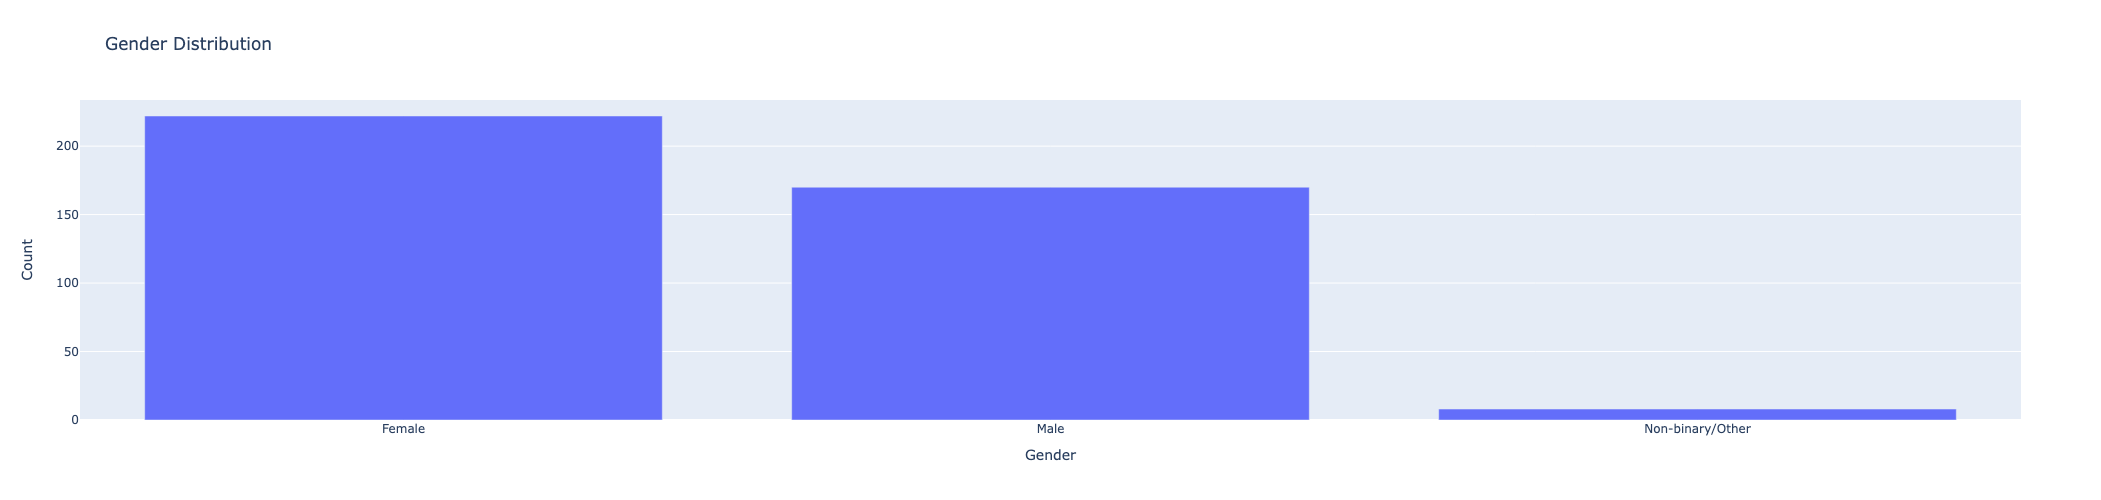

In [11]:
fig = px.bar(
    df['gender'].value_counts().reset_index(),
    x='index', y='gender',
    labels={'index':'Gender', 'gender':'Count'},
    title='Gender Distribution',
    height=500, width= 700)
fig.show()

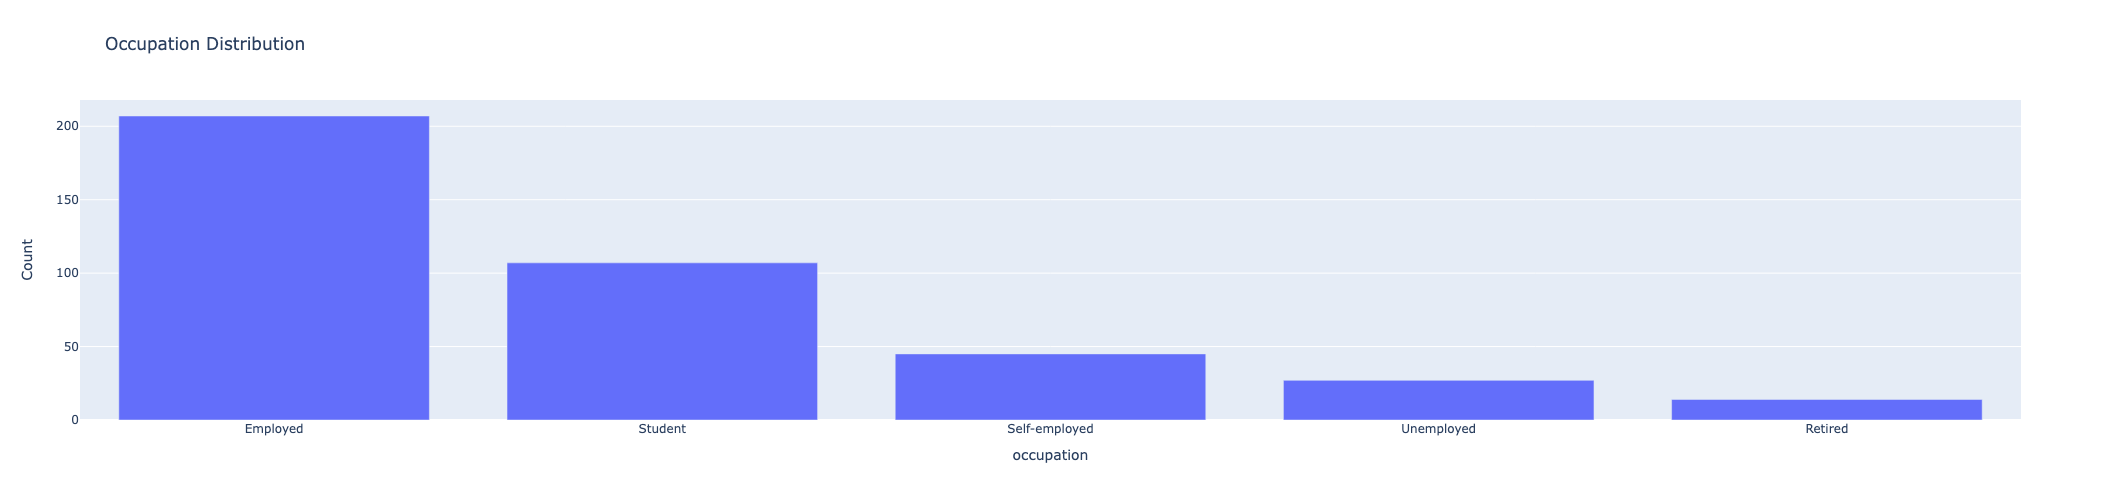

In [34]:
fig = px.bar(
    df['occupation'].value_counts().reset_index(),
    x='index', y='occupation',
    labels={'index':'occupation', 'occupation':'Count'},
    title='Occupation Distribution',
    height=500, width= 700)
fig.show()

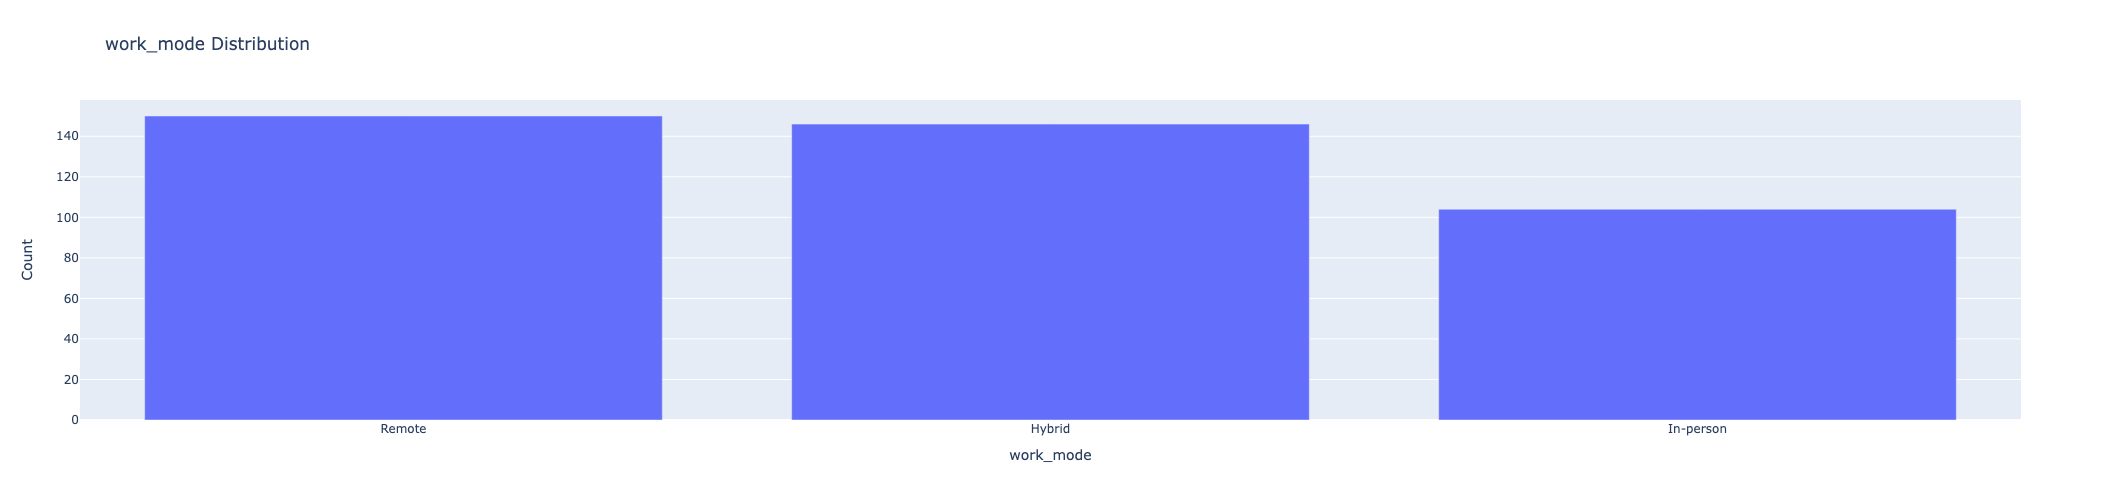

In [35]:
fig = px.bar(
    df['work_mode'].value_counts().reset_index(),
    x='index', y='work_mode',
    labels={'index':'work_mode', 'work_mode':'Count'},
    title='work_mode Distribution',
    height=500, width= 700)
fig.show()

- Average Screen Time, work screen hours and leisure screen hours by Gender

> 성별 차이는 없어 보임

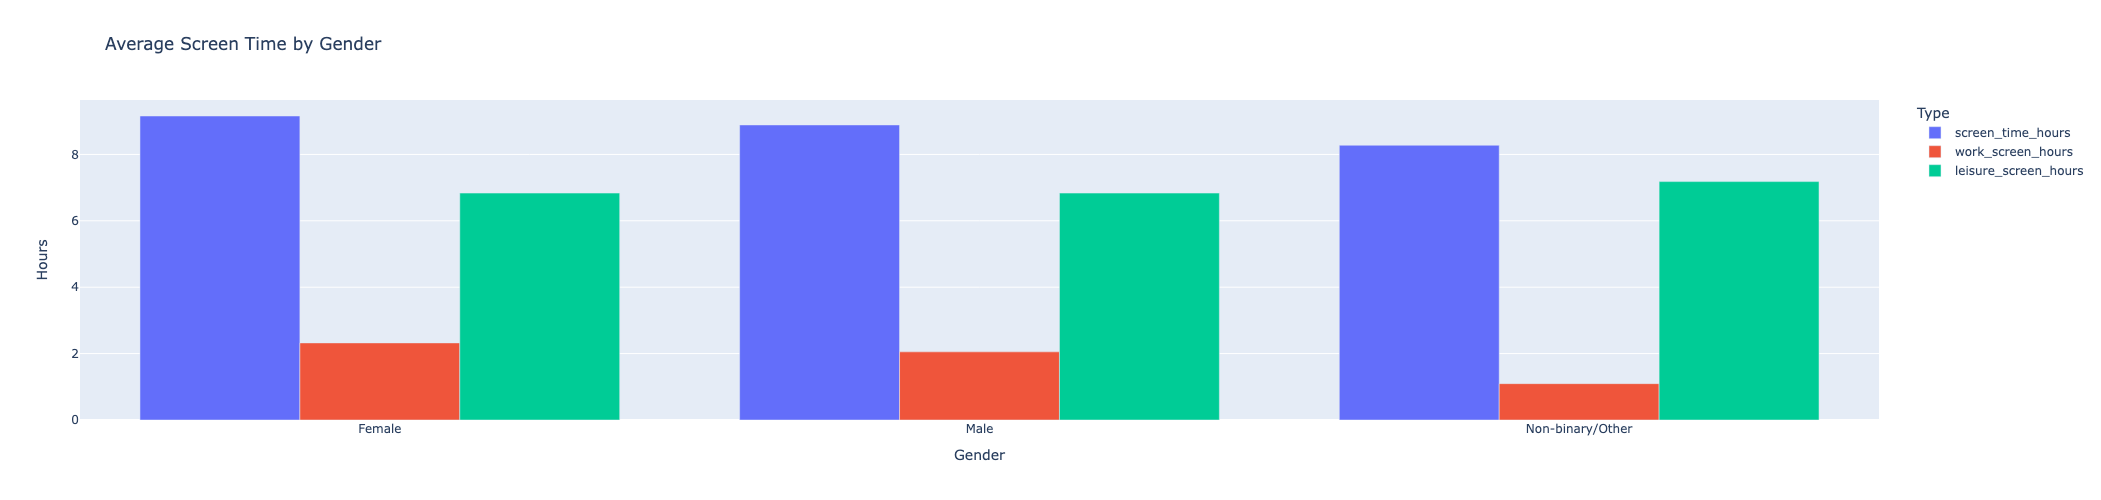

In [24]:
df_grouped = df.groupby("gender")[["screen_time_hours", "work_screen_hours","leisure_screen_hours"]].mean().reset_index()

fig = px.bar(
    df_grouped,
    x="gender", 
    y=["screen_time_hours", "work_screen_hours","leisure_screen_hours"],
    barmode="group",
    title="Average Screen Time by Gender",
    labels={"value": "Hours", "gender": "Gender", "variable": "Type"},
    width=700, height=500
)
fig.show()

- Average Screen Time, work screen hours and leisure screen hours by work mode

> remote로 하는 사람들이 당연히 work_xcreen_hours 가장 높았고 이에따라 screen time hours도 높았음

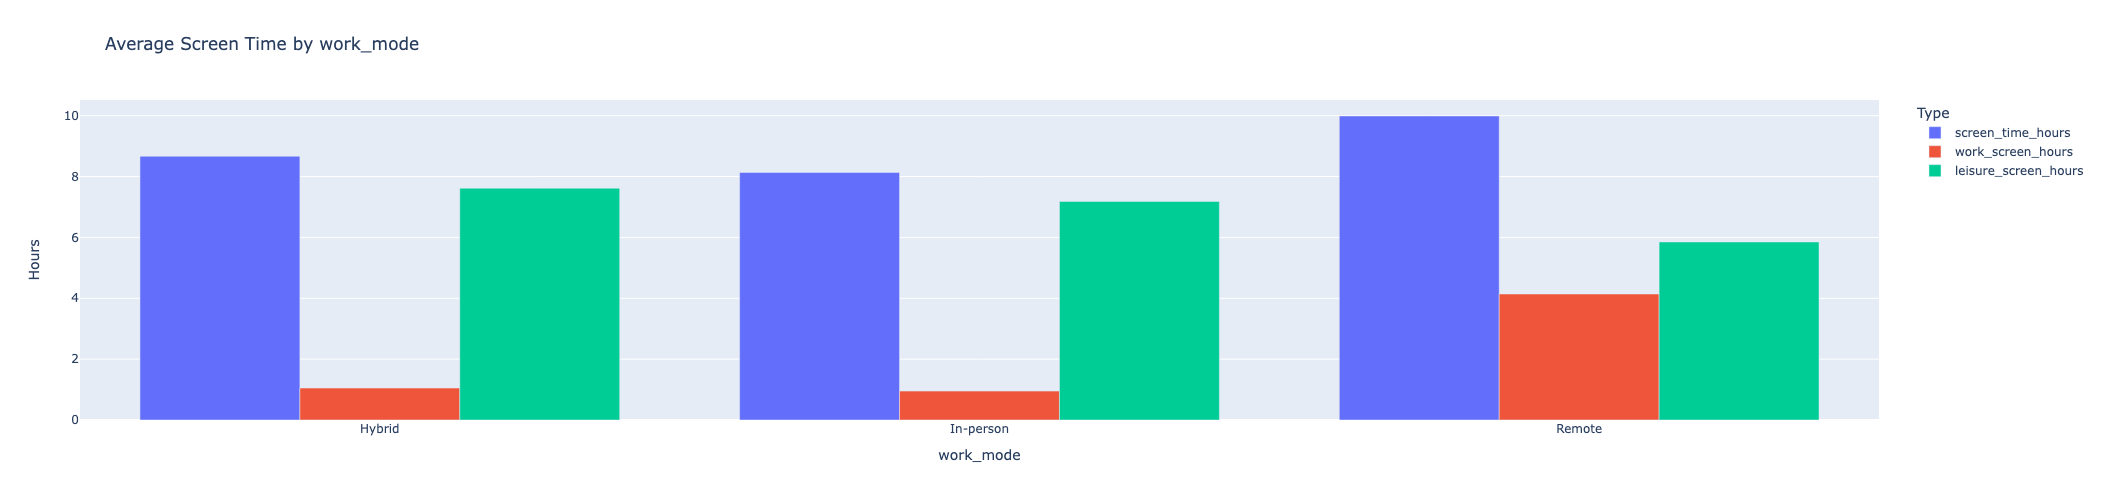

In [12]:
df_grouped = df.groupby("work_mode")[["screen_time_hours", "work_screen_hours","leisure_screen_hours"]].mean().reset_index()

fig = px.bar(
    df_grouped,
    x="work_mode", 
    y=["screen_time_hours", "work_screen_hours","leisure_screen_hours"],
    barmode="group",
    title="Average Screen Time by work_mode",
    labels={"value": "Hours", "work_mode": "work_mode", "variable": "Type"},
    width=700, height=500
)
fig.show()


- sleep quality 

> 다 왜 이렇게 낮아..ㅎㅎㅎ

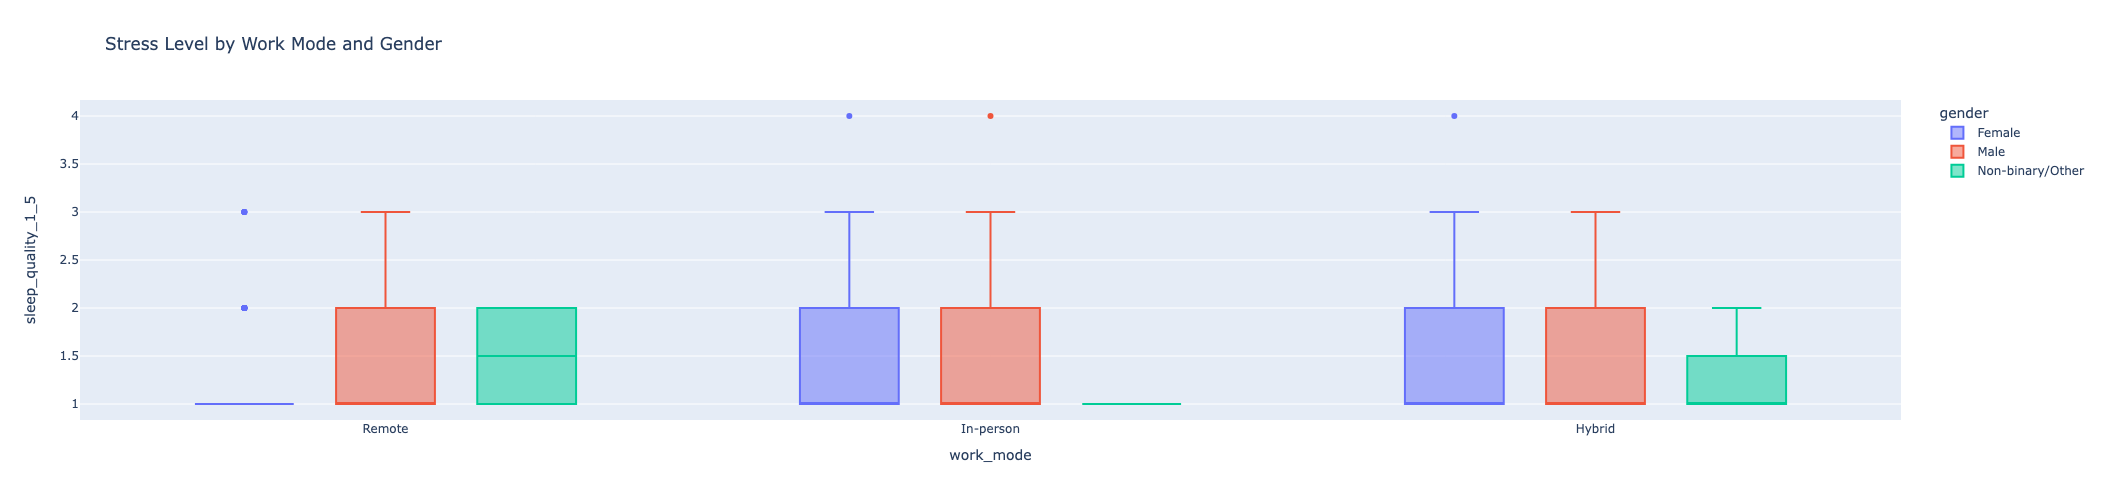

In [49]:
fig = px.box(
    df,
    x="work_mode",
    y="sleep_quality_1_5",
    color="gender",  
    title="Stress Level by Work Mode and Gender",
    height=500,
    width=700
)
fig.show()

- stress level

> remote에 비해 in-person,hybrid 의 stress level이 낮네?

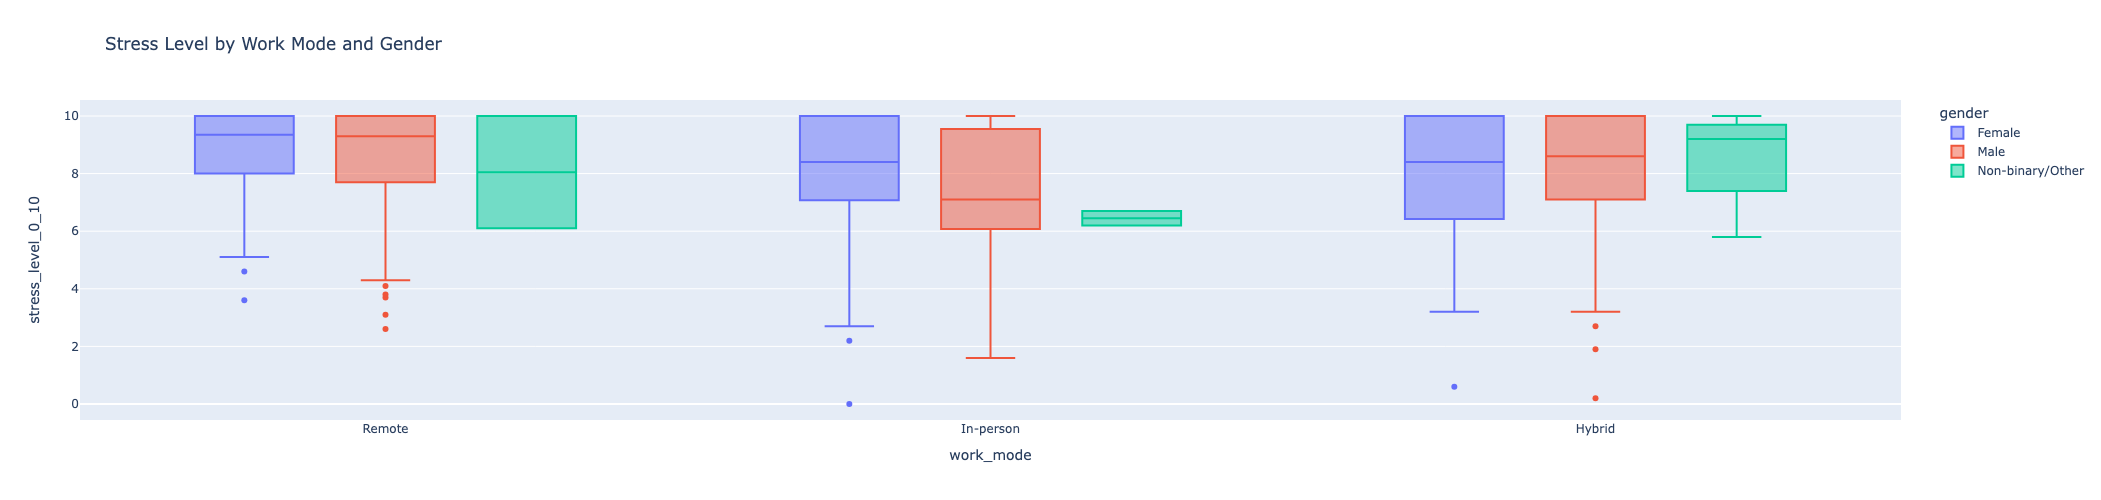

In [43]:
fig = px.box(
    df,
    x="work_mode",
    y="stress_level_0_10",
    color="gender",  
    title="Stress Level by Work Mode and Gender",
    height=500,
    width=700
)
fig.show()

- productivity

> in-person, hybrid가 remote에 비해 높은 경향

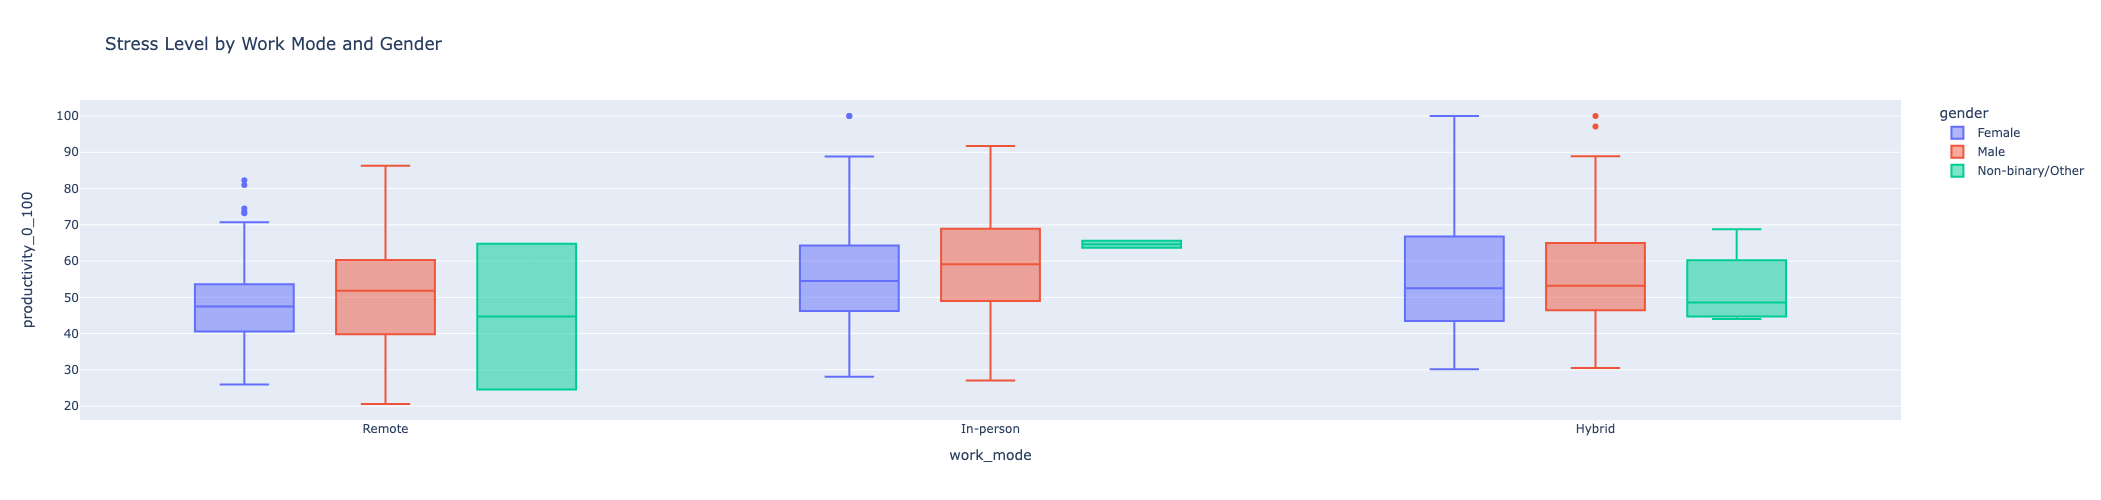

In [45]:
fig = px.box(
    df,
    x="work_mode",
    y="productivity_0_100",
    color="gender",   
    title="Stress Level by Work Mode and Gender",
    height=500,
    width=700
)
fig.show()

In [ ]:
occupation

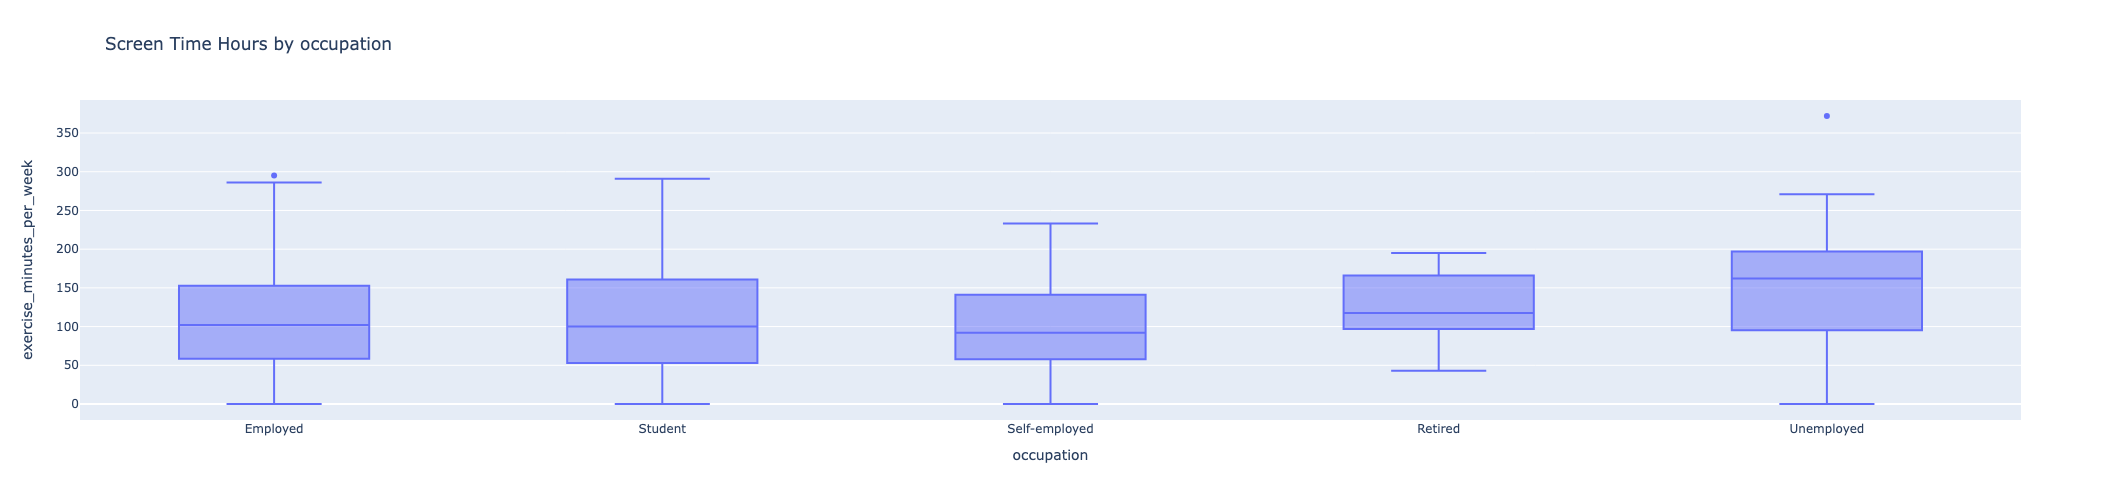

In [47]:

fig = px.box(
    df,
    x="occupation",
    y="exercise_minutes_per_week",
    title="Screen Time Hours by occupation",
    height=500, width= 700)
fig.show()

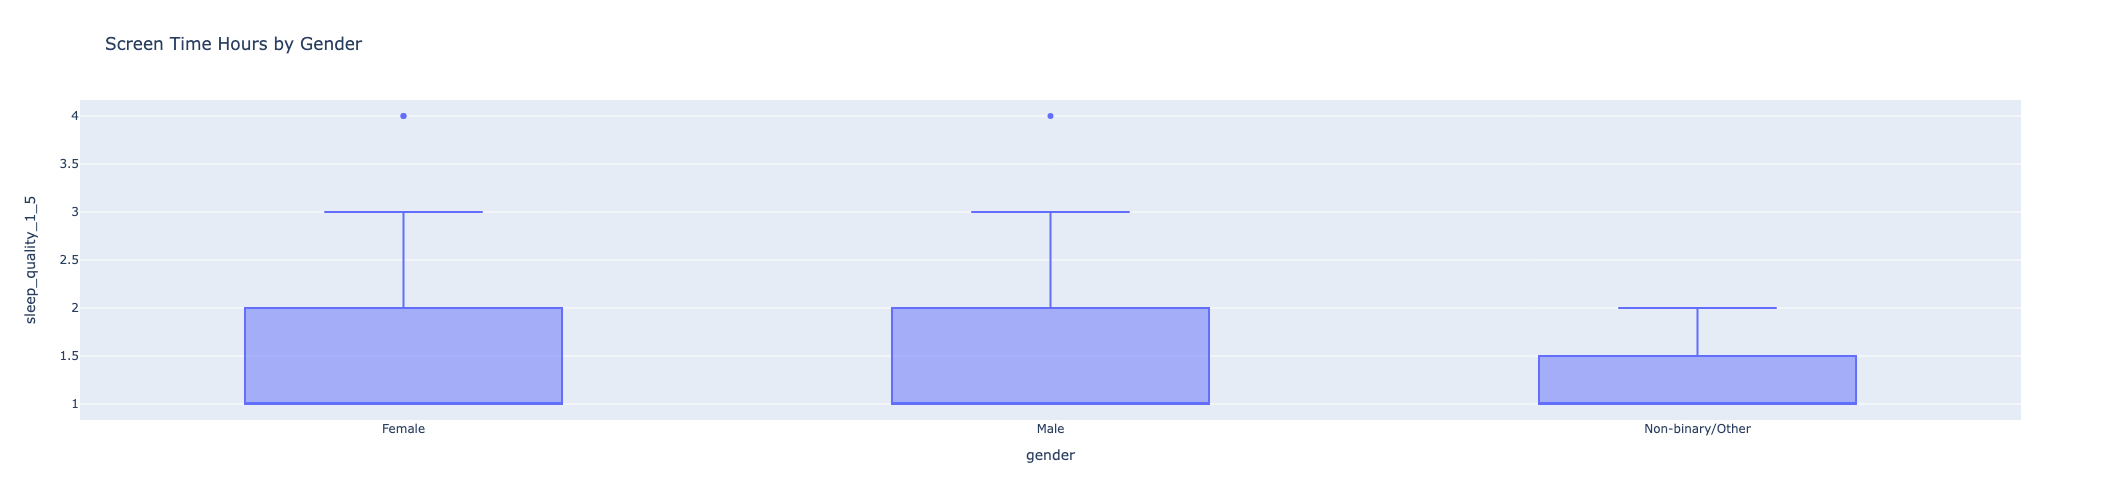

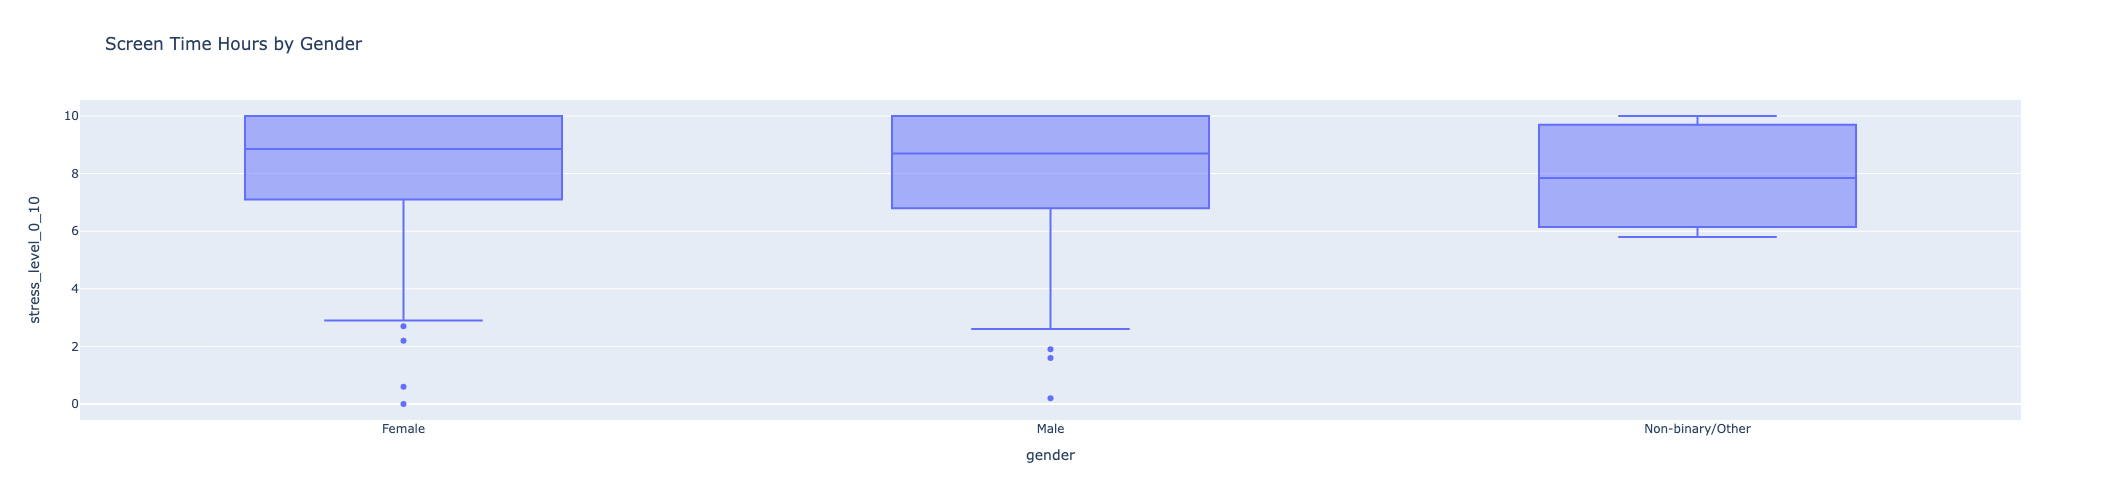

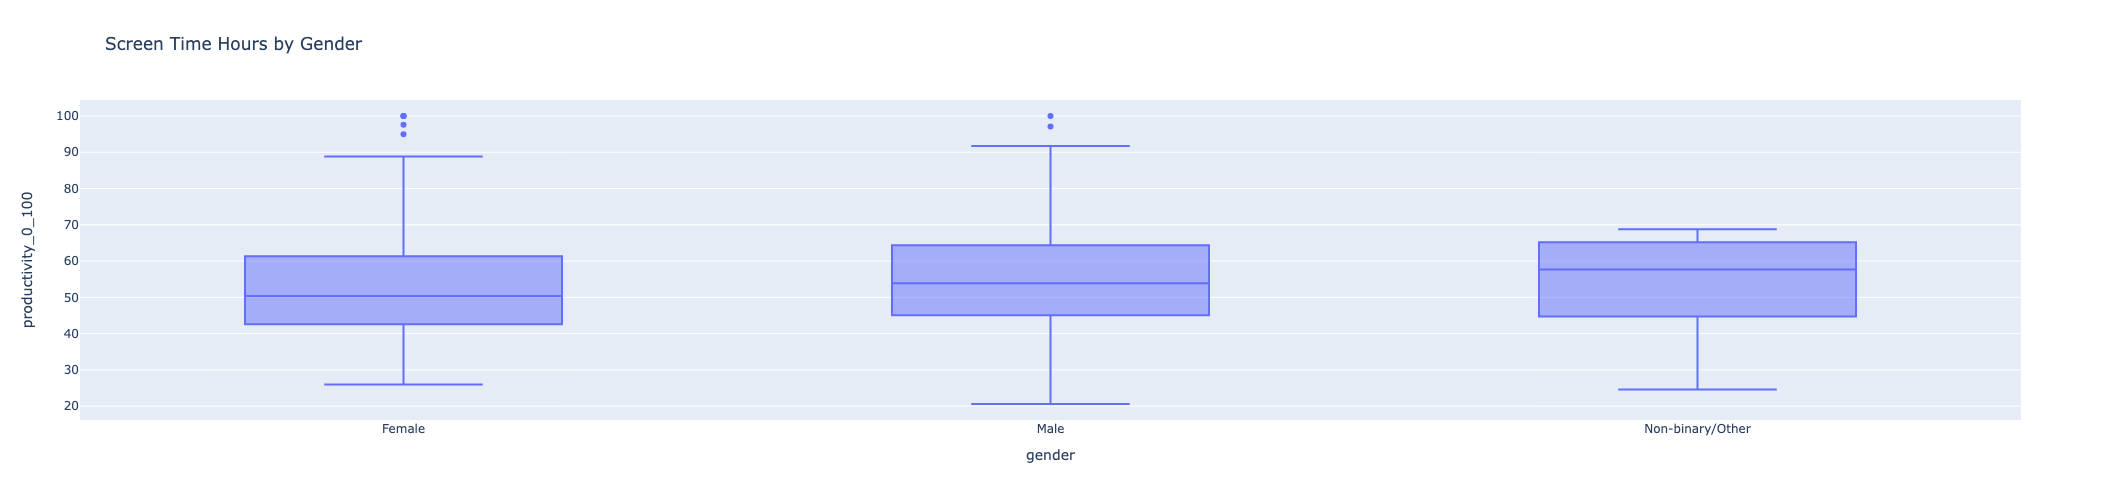

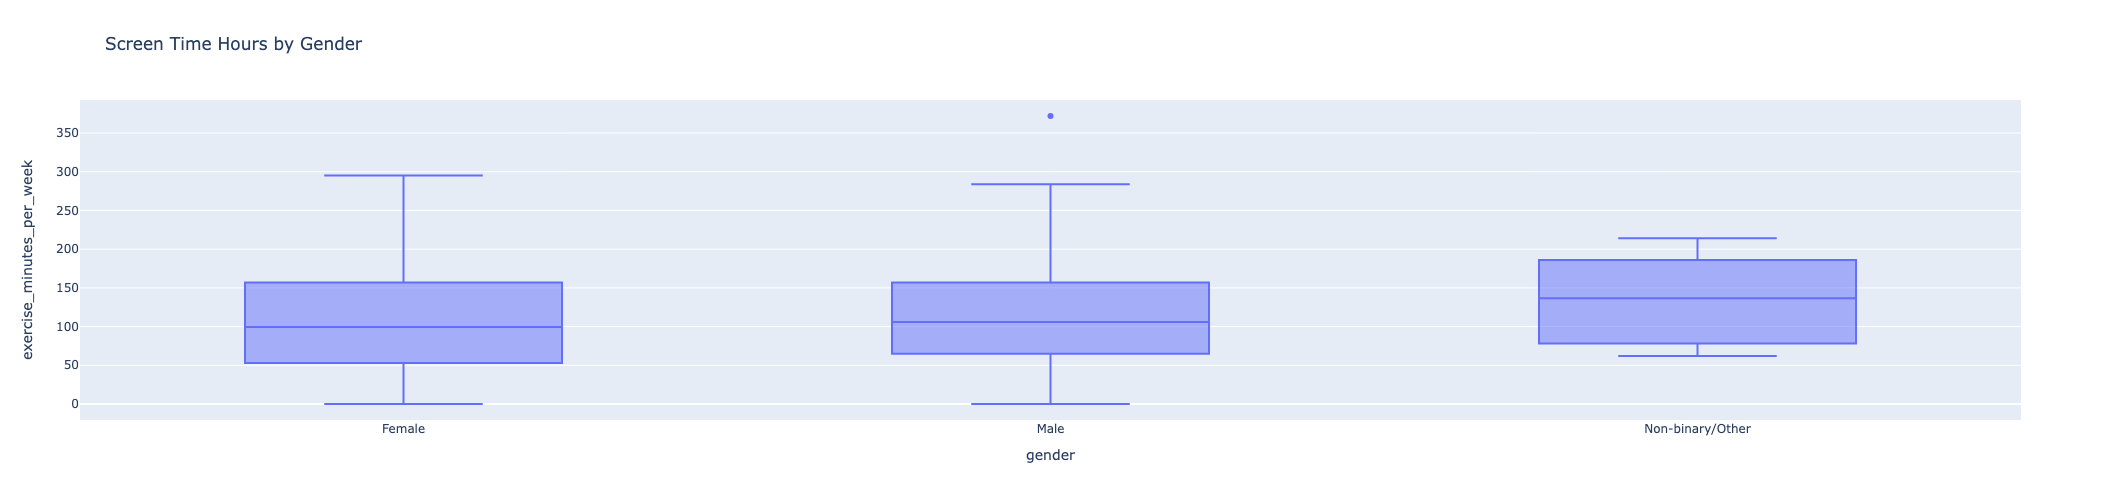

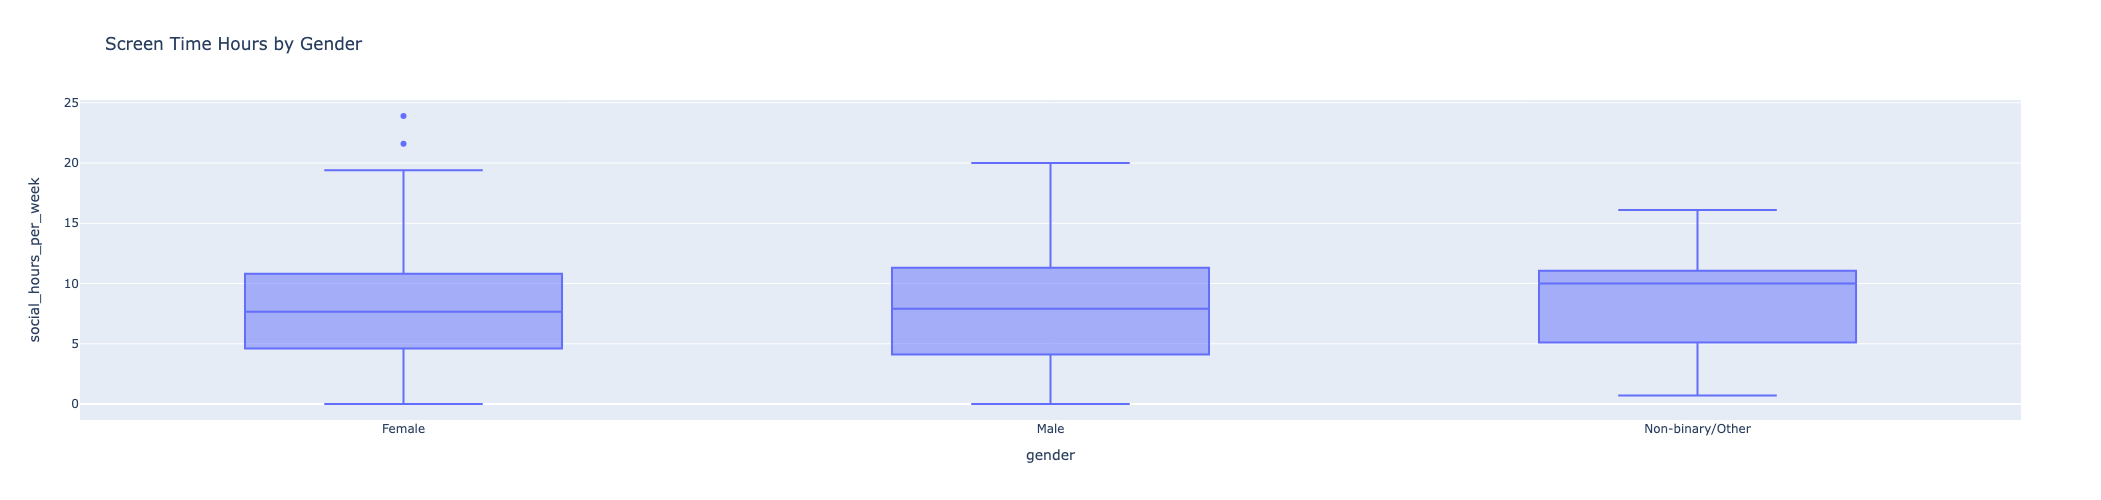

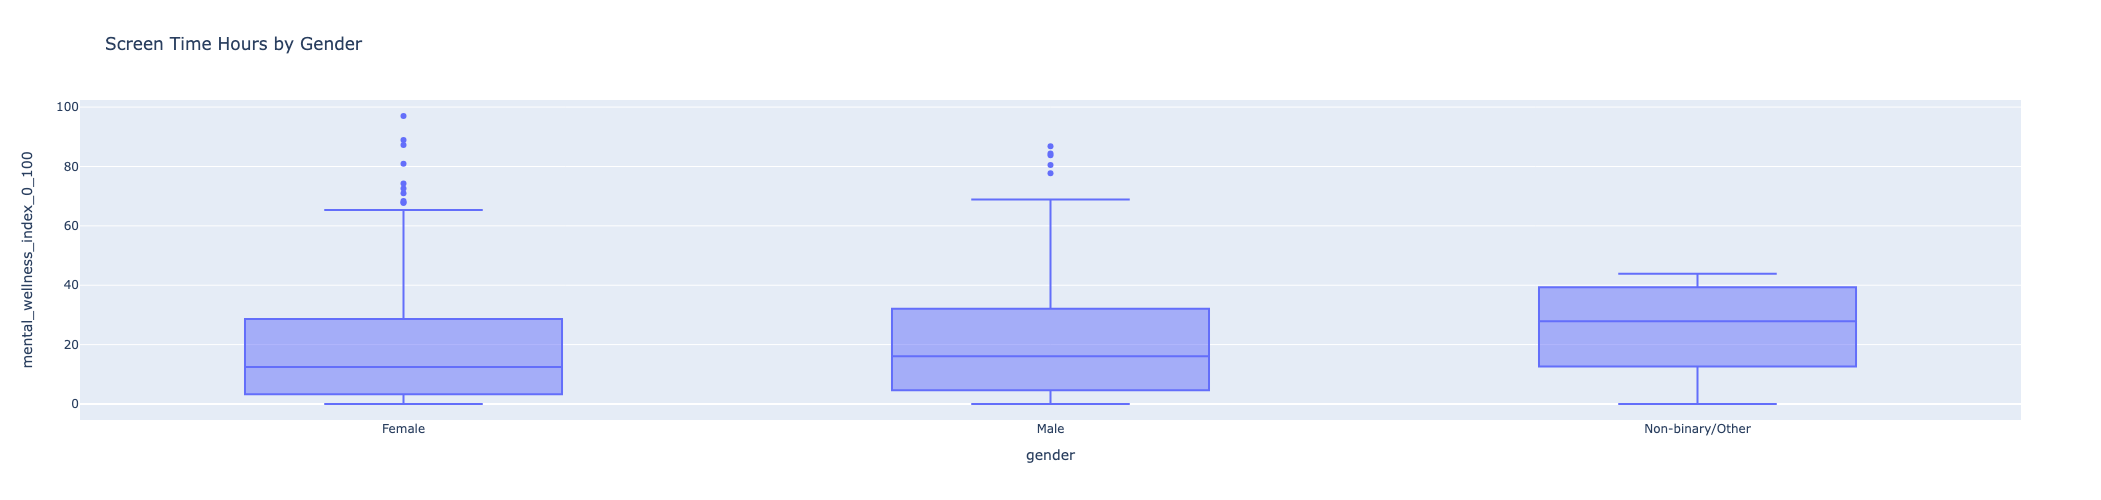

In [9]:

fig = px.box(
    df,
    x="gender",
    y="exercise_minutes_per_week",
    title="Screen Time Hours by Gender",
    height=500, width= 700)
fig.show()
fig = px.box(
    df,
    x="gender",
    y="social_hours_per_week",
    title="Screen Time Hours by Gender",
    height=500, width= 700)
fig.show()
fig = px.box(
    df,
    x="gender",
    y="mental_wellness_index_0_100",
    title="Screen Time Hours by Gender",
    height=500, width= 700)
fig.show()

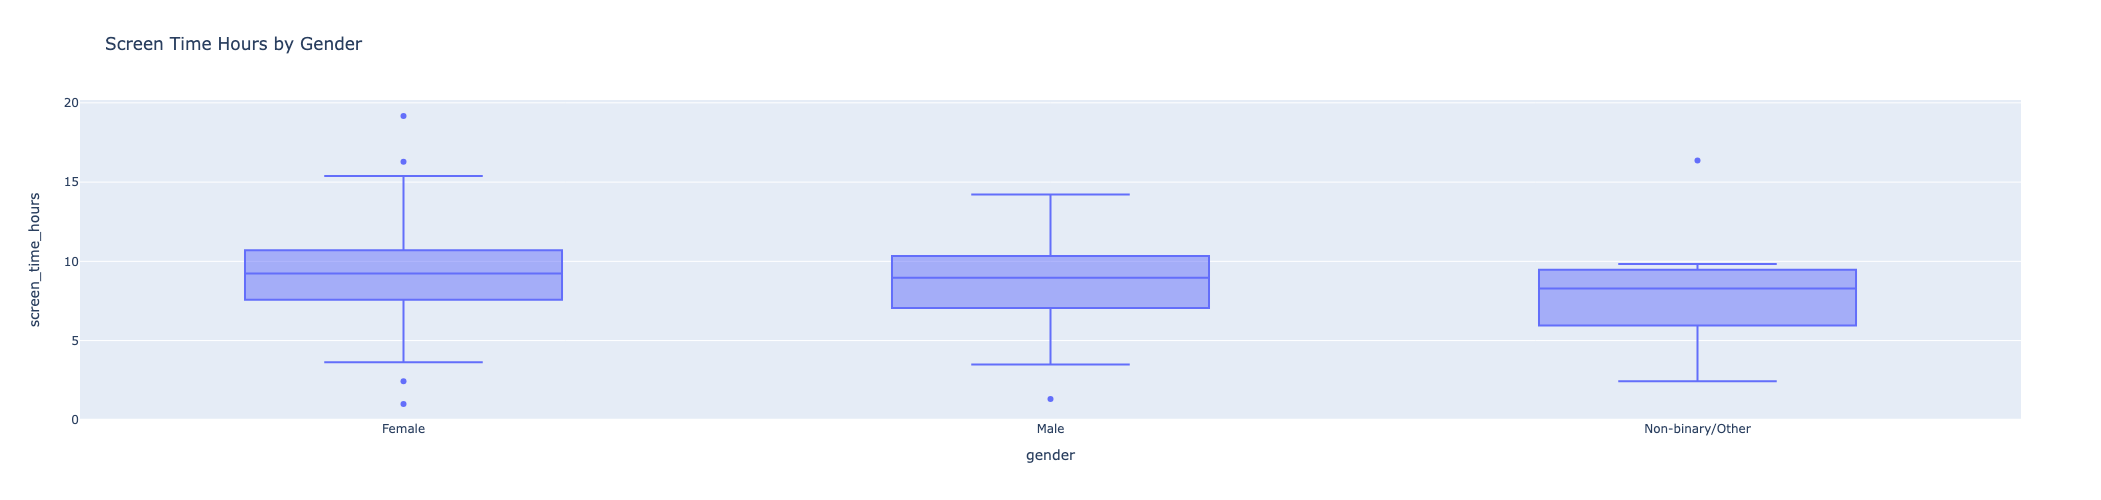

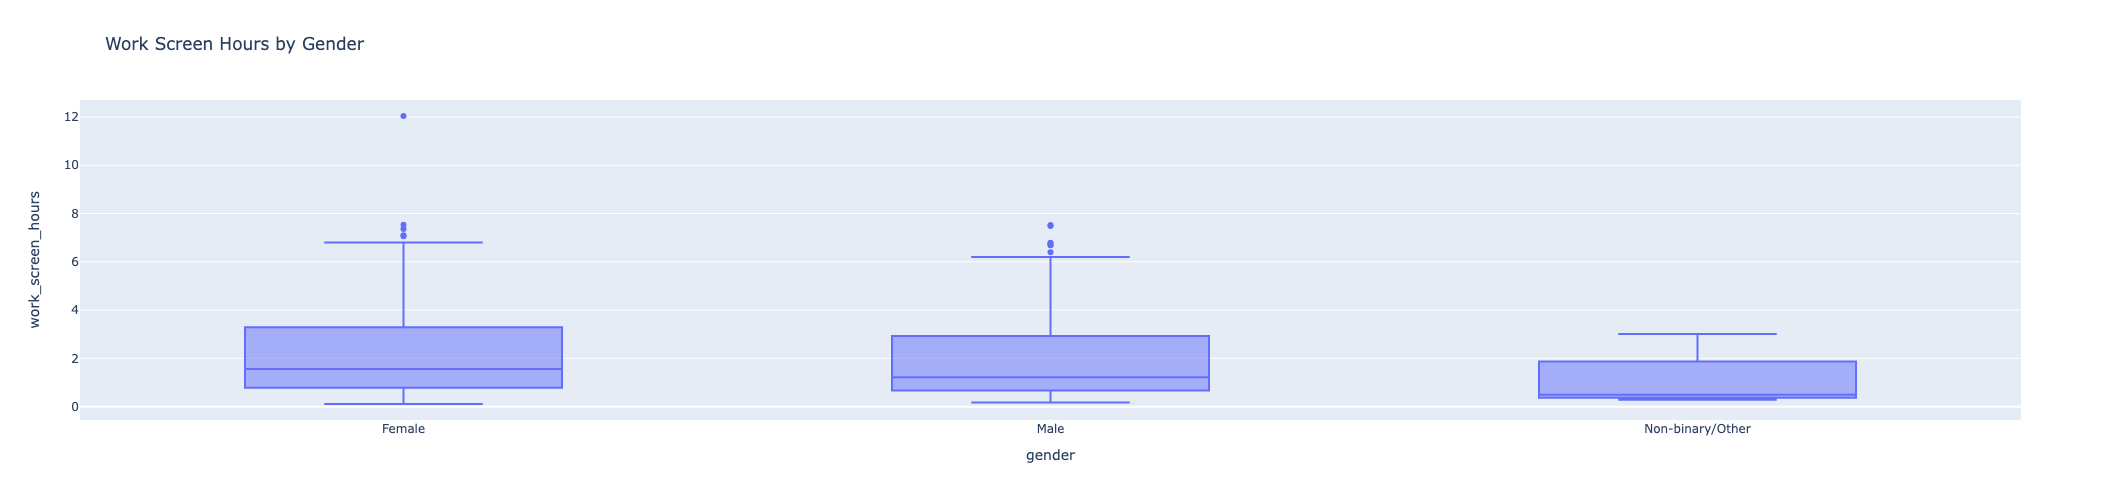

In [10]:
fig = px.box(
    df,
    x="gender",
    y="screen_time_hours",
    title="Screen Time Hours by Gender",
    height=500, width= 700)
fig.show()

fig = px.box(
    df,
    x="gender",
    y="work_screen_hours",
    title="Work Screen Hours by Gender",
    height=500, width= 700)
fig.show()


In [ ]:

fig = px.scatter(
    df, 
    x="screen_time_hours", 
    y="sleep_hours", 
    trendline="ols",  # 추세선(optional)
    title="Screen Time vs Sleep Hours"
)
fig.show()